* Financial Document Q&A — RAG with Semantic Search (sentence-transformers + ChromaDB) + Logistic Regression re-ranker
* Based on: https://github.com/Suhicode/rag-document-qa-system

In [1]:
!pip install sentence-transformers chromadb

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from pathlib import Path
from collections import Counter

from sentence_transformers import SentenceTransformer
import chromadb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline



# 1. Load Data

Each `.txt` file in `data/financial_docs/` is one 10-K report.  
File naming: `AAPL_10K_2024.txt`, `MSFT_10K_2024.txt`, etc.

In [3]:
def load_txt_files(directory_path):
    """Load all .txt files from a folder. Returns a list of dicts."""
    documents = []
    data_dir = Path(directory_path)

    if not data_dir.exists():
        print(f"Directory '{directory_path}' not found.")
        return []

    for file_path in data_dir.glob('*.txt'):
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            text = f.read()

        parts = file_path.stem.replace('-', '_').split('_')
        ticker = parts[0] if parts else 'UNKNOWN'
        year = next((p for p in parts if len(p) == 4 and p.isdigit()), '2024')

        documents.append({
            'ticker': ticker,
            'year': year,
            'text': text,
            'filename': file_path.name
        })
        print(f"  Loaded: {ticker} ({year}) — {len(text):,} chars")

    print(f"\nTotal documents loaded: {len(documents)}")
    return documents


documents = load_txt_files('data/financial_docs/')

  Loaded: AAPL (2024) — 209,637 chars
  Loaded: AMZN (2024) — 287,162 chars
  Loaded: GOOGL (2024) — 349,037 chars
  Loaded: JPM (2024) — 1,206,841 chars
  Loaded: META (2024) — 520,807 chars
  Loaded: MSFT (2024) — 362,200 chars
  Loaded: NVDA (2024) — 343,528 chars
  Loaded: TSLA (2024) — 400,200 chars
  Loaded: V (2024) — 435,689 chars

Total documents loaded: 9


In [4]:
if documents:
    doc = documents[0]
    print(f"Ticker : {doc['ticker']}")
    print(f"Year   : {doc['year']}")
    print(f"Preview: {doc['text'][:300]}...")

Ticker : AAPL
Year   : 2024
Preview: 
 
UNITED STATES
SECURITIES AND EXCHANGE COMMISSION
Washington, D.C. 20549
 
FORM 10-K
 
(Mark One)
☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934
For the fiscal year ended September 27, 2025
or
☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURI...


# 2. Clean Data

In [5]:
def clean_text(text):
    """Remove noise from SEC document text."""
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'FORM 10-[KQ]', '', text, flags=re.IGNORECASE)
    text = re.sub(r'Table of Contents', '', text, flags=re.IGNORECASE)
    text = re.sub(r'Page \d+', '', text)
    return text.strip()


for doc in documents:
    doc['text_clean'] = clean_text(doc['text'])
    print(f"  {doc['ticker']}: {len(doc['text']):,} → {len(doc['text_clean']):,} chars")

print("\nCleaning done!")

  AAPL: 209,637 → 205,340 chars
  AMZN: 287,162 → 281,172 chars
  GOOGL: 349,037 → 341,211 chars
  JPM: 1,206,841 → 1,169,810 chars
  META: 520,807 → 512,711 chars
  MSFT: 362,200 → 312,497 chars
  NVDA: 343,528 → 337,889 chars
  TSLA: 400,200 → 394,066 chars
  V: 435,689 → 427,899 chars

Cleaning done!


# 3. Create Chunks

Split each document into overlapping 1000-char windows.  
We skip the first 5000 chars (table of contents).

In [6]:
def create_chunks(text, chunk_size=1000, overlap=100):
    """Split text into overlapping chunks of fixed size."""
    chunks = []
    start = 0
    while start < len(text):
        chunk = text[start : start + chunk_size]
        if len(chunk.strip()) > 100:
            chunks.append(chunk)
        start += chunk_size - overlap
    return chunks


all_chunks = []

for doc in documents:
    # skip first 5000 chars = table of contents
    chunks = create_chunks(doc['text_clean'][5000:])
    for i, chunk_text in enumerate(chunks):
        all_chunks.append({
            'chunk_id': f"{doc['ticker']}_chunk_{i}",
            'ticker':   doc['ticker'],
            'year':     doc['year'],
            'text':     chunk_text,
            'chunk_length': len(chunk_text),
            'word_count':   len(chunk_text.split())
        })
    print(f"  {doc['ticker']}: {len(chunks):,} chunks")

chunks_df = pd.DataFrame(all_chunks)
print(f"\nTotal chunks: {len(chunks_df):,}")

  AAPL: 223 chunks
  AMZN: 307 chunks
  GOOGL: 374 chunks
  JPM: 1,295 chunks
  META: 565 chunks
  MSFT: 342 chunks
  NVDA: 370 chunks
  TSLA: 433 chunks
  V: 470 chunks

Total chunks: 4,379


In [7]:
chunks_df.head()

,chunk_id,ticker,year,text,chunk_length,word_count
0,AAPL_chunk_0,AAPL,2024,filed with the U.S. Securities and Exchange C...,1000,159
1,AAPL_chunk_1,AAPL,2024,52 Item 9B. Other Information 53 Item 9C. Disc...,1000,146
2,AAPL_chunk_2,AAPL,2024,scussion and Analysis of Financial Condition a...,1000,136
3,AAPL_chunk_3,AAPL,2024,"might cause such differences include, but are ...",1000,155
4,AAPL_chunk_4,AAPL,2024,services. The Company’s fiscal year is the 52...,1000,160


# 4. Exploratory Data Analysis (EDA)

In [8]:
print("Chunks per company:")
print(chunks_df['ticker'].value_counts().sort_index())
print()
print("Chunk length stats:")
print(chunks_df['chunk_length'].describe().round(1))

Chunks per company:
ticker
AAPL      223
AMZN      307
GOOGL     374
JPM      1295
META      565
MSFT      342
NVDA      370
TSLA      433
V         470
Name: count, dtype: int64

Chunk length stats:
count    4379.0
mean      999.0
std        24.8
min       111.0
25%      1000.0
50%      1000.0
75%      1000.0
max      1000.0
Name: chunk_length, dtype: float64


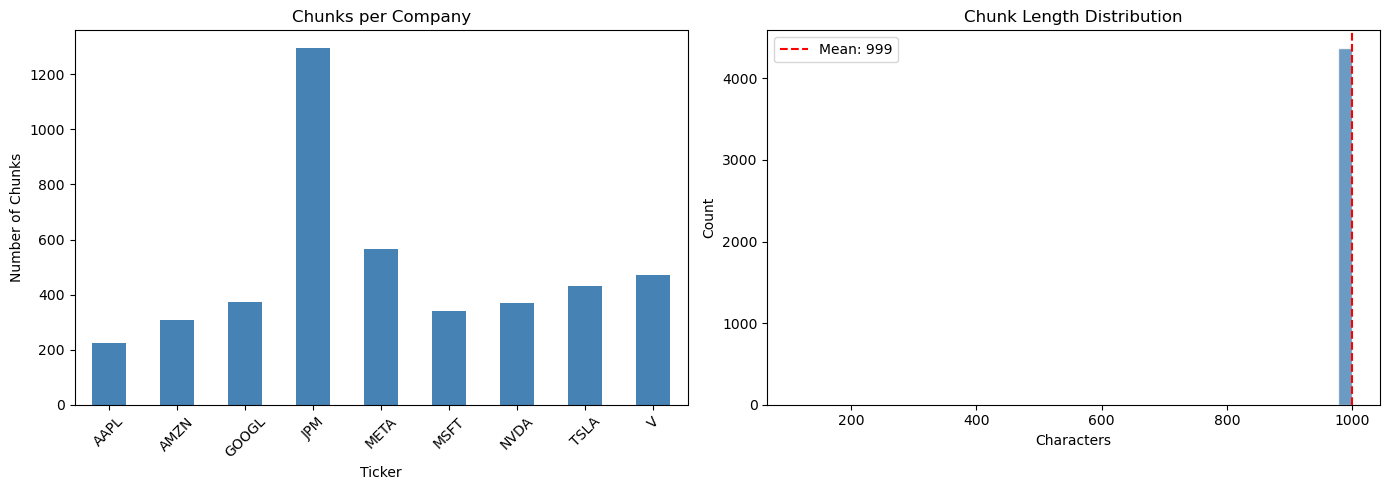

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

chunks_per_company = chunks_df['ticker'].value_counts().sort_index()
chunks_per_company.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Chunks per Company')
axes[0].set_xlabel('Ticker')
axes[0].set_ylabel('Number of Chunks')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(chunks_df['chunk_length'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(chunks_df['chunk_length'].mean(), color='red', linestyle='--',
                label=f"Mean: {chunks_df['chunk_length'].mean():.0f}")
axes[1].set_title('Chunk Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

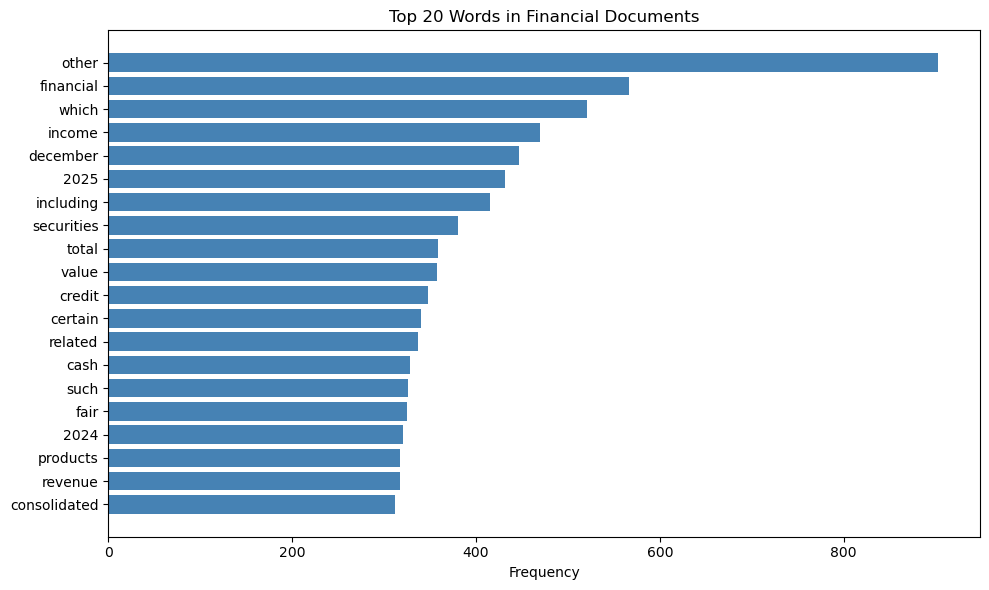

In [10]:
all_words = ' '.join(chunks_df['text'].sample(min(1000, len(chunks_df)))).lower().split()
stopwords = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with','by',
    'from','as','is','was','are','were','been','be','have','has','had','do',
    'does','did','will','would','could','should','may','might','must','can',
    'this','that','these','those','i','you','he','she','it','we','they'
}
words = [w for w in all_words if w not in stopwords and len(w) > 3]
top_words = dict(Counter(words).most_common(20))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(list(top_words.keys()), list(top_words.values()), color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 20 Words in Financial Documents')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

# 5. Semantic Embeddings (sentence-transformers)

**Why embeddings?**  
Keyword search finds chunks that *contain* query words — but misses meaning.  
Sentence-transformers convert text into 384-dimensional vectors so that  
*similar meaning → similar vector*, regardless of exact words used.

> Model: `all-MiniLM-L6-v2` — same model used in the reference project  
> (github.com/Suhicode/rag-document-qa-system)

In [11]:
# Load embedding model
# Source: https://github.com/Suhicode/rag-document-qa-system — vector_store.py
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Model loaded: all-MiniLM-L6-v2")
print(f"Embedding dimension: {embedding_model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: all-MiniLM-L6-v2
Embedding dimension: 384


In [12]:
# Encode all chunks — this may take 1-3 minutes
print(f"Encoding {len(chunks_df)} chunks...")
texts = chunks_df['text'].tolist()
embeddings = embedding_model.encode(texts, batch_size=64, show_progress_bar=True)
print(f"\nEmbeddings shape: {embeddings.shape}")

Encoding 4379 chunks...


Batches:   0%|          | 0/69 [00:00<?, ?it/s]


Embeddings shape: (4379, 384)


# 6. ChromaDB Vector Store

Store all embeddings in ChromaDB for fast similarity search.  
Based on the same pattern as the reference project.

In [13]:
# Source: https://github.com/Suhicode/rag-document-qa-system — vector_store.py
chroma_client = chromadb.Client()

# Delete collection if already exists (for re-runs)
try:
    chroma_client.delete_collection("financial_docs")
except:
    pass

collection = chroma_client.create_collection(
    name="financial_docs",
    metadata={"hnsw:space": "cosine"}   # cosine similarity
)

# Add all chunks to ChromaDB
collection.add(
    ids=chunks_df['chunk_id'].tolist(),
    embeddings=embeddings.tolist(),
    documents=chunks_df['text'].tolist(),
    metadatas=[
        {'ticker': row['ticker'], 'year': row['year']}
        for _, row in chunks_df.iterrows()
    ]
)

print(f"Stored {collection.count()} chunks in ChromaDB")

Stored 4379 chunks in ChromaDB


# 7. Modelling — Logistic Regression Re-ranker

## 7.1 Create Training Data

Now we use **semantic similarity** (cosine score from ChromaDB) as the main feature —  
not keyword overlap. This is the key improvement over the keyword-based version.

| Feature | What it measures |
|---|---|
| `semantic_score` | cosine similarity between query and chunk (0–1) |
| `chunk_length_norm` | chunk length / 1000 |
| `has_numbers` | financial numbers ($, %) in chunk |

In [14]:
def financial_score(text):
    """Count financial numbers in text (dollars, percentages, large numbers)."""
    numbers = len(re.findall(r'\$[\d,.]+|\d+\.\d+%|\d{1,3}(?:,\d{3})+', text))
    return min(numbers / 5, 1.0)


def create_training_data(queries, collection, embedding_model, chunks_df, top_k=20):
    """
    Build labelled dataset using semantic similarity.
    Positive: top-k most similar chunks (relevant=1)
    Negative: bottom-k least similar chunks (relevant=0)
    """
    training_data = []

    for query in queries:
        query_embedding = embedding_model.encode([query])[0].tolist()

        # Get ALL chunks ranked by semantic similarity
        results = collection.query(
            query_embeddings=[query_embedding],
            n_results=min(collection.count(), 100),
            include=['documents', 'distances', 'metadatas']
        )

        docs      = results['documents'][0]
        distances = results['distances'][0]   # cosine distance (lower = more similar)

        n = top_k // 2

        # Positive examples: most similar (lowest distance)
        for doc, dist in zip(docs[:n], distances[:n]):
            semantic_score = 1 - dist   # convert distance → similarity
            training_data.append({
                'semantic_score':    semantic_score,
                'chunk_length_norm': len(doc) / 1000,
                'has_numbers':       financial_score(doc),
                'is_relevant':       1
            })

        # Negative examples: least similar (highest distance)
        for doc, dist in zip(docs[-n:], distances[-n:]):
            semantic_score = 1 - dist
            training_data.append({
                'semantic_score':    semantic_score,
                'chunk_length_norm': len(doc) / 1000,
                'has_numbers':       financial_score(doc),
                'is_relevant':       0
            })

    return pd.DataFrame(training_data)


queries = [
    "What is the total revenue?",
    "Tell me about risk factors",
    "How much cash does the company have?",
    "What are the operating expenses?",
    "Describe the business segments",
    "What is the net income?",
    "Tell me about total assets",
    "What are major risks?",
    "How did the company perform?",
    "What is the profit margin?"
]

training_df = create_training_data(queries, collection, embedding_model, chunks_df)

print(f"Training examples : {len(training_df)}")
print(f"Relevant (1)      : {(training_df['is_relevant']==1).sum()}")
print(f"Not relevant (0)  : {(training_df['is_relevant']==0).sum()}")
print(f"\nAvg semantic_score (relevant)    : {training_df[training_df['is_relevant']==1]['semantic_score'].mean():.3f}")
print(f"Avg semantic_score (not relevant): {training_df[training_df['is_relevant']==0]['semantic_score'].mean():.3f}")

Training examples : 200
Relevant (1)      : 100
Not relevant (0)  : 100

Avg semantic_score (relevant)    : 0.546
Avg semantic_score (not relevant): 0.426


In [15]:
training_df.head(10)

,semantic_score,chunk_length_norm,has_numbers,is_relevant
0,0.622577,1.0,1.0,1
1,0.621453,1.0,1.0,1
2,0.607463,1.0,0.0,1
3,0.607351,1.0,1.0,1
4,0.598996,1.0,1.0,1
5,0.580246,1.0,1.0,1
6,0.578914,1.0,0.0,1
7,0.576919,1.0,1.0,1
8,0.576092,1.0,0.6,1
9,0.574019,1.0,1.0,1


## 7.2 Train / Test Split

In [16]:
feature_cols = ['semantic_score', 'chunk_length_norm', 'has_numbers']

X = training_df[feature_cols]
y = training_df['is_relevant']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} examples")
print(f"Test : {len(X_test)} examples")

Train: 160 examples
Test : 40 examples


## 7.3 Train Model

In [17]:
model = Pipeline([
    ('scaler',     StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

model.fit(X_train, y_train)
print("Model trained!")

Model trained!


## 7.4 Evaluate Model

In [18]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.1%}\n")
print(classification_report(y_test, y_pred, target_names=['Not Relevant', 'Relevant']))

Accuracy: 92.5%

              precision    recall  f1-score   support

Not Relevant       0.90      0.95      0.93        20
    Relevant       0.95      0.90      0.92        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



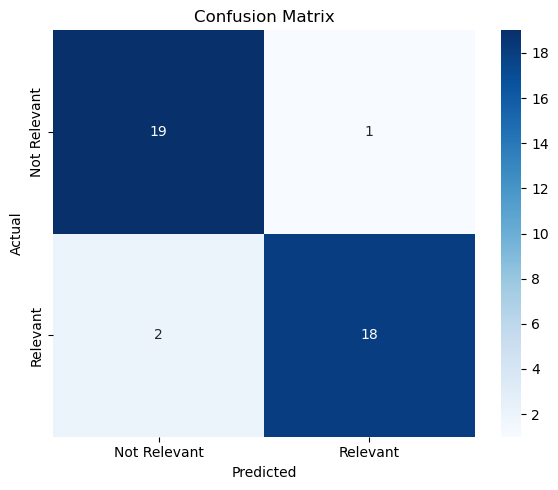

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Relevant', 'Relevant'],
            yticklabels=['Not Relevant', 'Relevant'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 7.5 Feature Importance

Logistic Regression coefficients:
  semantic_score         +2.256
  chunk_length_norm      -0.774
  has_numbers            -0.246


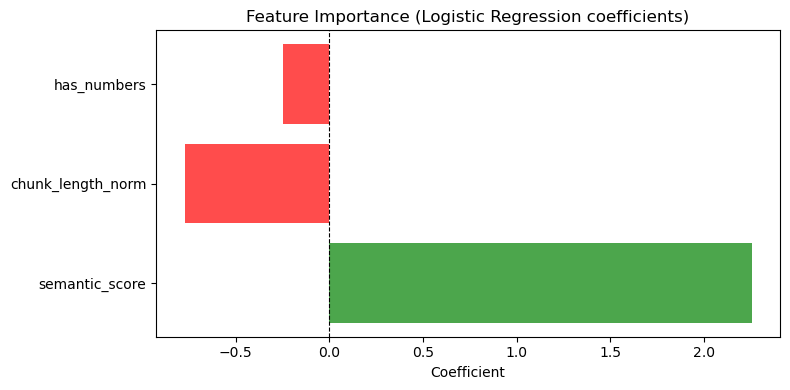

In [20]:
coefficients = model.named_steps['classifier'].coef_[0]

print("Logistic Regression coefficients:")
for feat, coef in zip(feature_cols, coefficients):
    print(f"  {feat:<22} {coef:+.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['green' if c > 0 else 'red' for c in coefficients]
ax.barh(feature_cols, coefficients, color=colors, alpha=0.7)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Feature Importance (Logistic Regression coefficients)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

# 8. Retrieval System

**Two-step retrieval:**
1. **Semantic search** (ChromaDB) — find top-k candidates by cosine similarity  
2. **ML re-ranking** (Logistic Regression) — score each candidate and return top-n

This is the same pattern used in production RAG systems.

In [21]:
def search_documents(question, collection, embedding_model, model, top_k=20, top_n=3, ticker=None):
    """
    Find the most relevant chunks for a given question.
    Step 1: semantic search via ChromaDB
    Step 2: Logistic Regression re-ranking
    
    Based on: https://github.com/Suhicode/rag-document-qa-system
    """
    # Embed the question
    query_embedding = embedding_model.encode([question])[0].tolist()

    # Build filter for ticker if specified
    where = {"ticker": ticker} if ticker else None

    # Step 1: semantic search
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=top_k,
        where=where,
        include=['documents', 'distances', 'metadatas']
    )

    docs      = results['documents'][0]
    distances = results['distances'][0]
    metadatas = results['metadatas'][0]

    # Step 2: build features for ML re-ranker
    feats = []
    for doc, dist in zip(docs, distances):
        feats.append({
            'semantic_score':    1 - dist,
            'chunk_length_norm': len(doc) / 1000,
            'has_numbers':       financial_score(doc)
        })

    probs = model.predict_proba(pd.DataFrame(feats))[:, 1]
    order = np.argsort(probs)[::-1][:top_n]

    print(f"Question: {question}\n")
    for rank, i in enumerate(order, 1):
        ticker_label = metadatas[i]['ticker']
        print(f"Result {rank} | {ticker_label} | Relevance: {probs[i]:.1%}")
        print(f"  {docs[i][:500]}...\n")

    return [(docs[i], metadatas[i], probs[i]) for i in order]

In [22]:
results = search_documents(
    question="What is the Apple revenue in 2024?",
    collection=collection,
    embedding_model=embedding_model,
    model=model,
    ticker="AAPL"
)

Question: What is the Apple revenue in 2024?

Result 1 | AAPL | Relevance: 99.5%
  les increased during 2025 compared to 2024 due to higher net sales of Pro models. Mac Mac net sales increased during 2025 compared to 2024 primarily due to higher net sales of laptops and desktops. iPad iPad net sales increased during 2025 compared to 2024 primarily due to higher net sales of iPad Air, iPad mini and iPad, partially offset by lower net sales of iPad Pro. Wearables, Home and Accessories Wearables, Home and Accessories net sales decreased during 2025 compared to 2024 primarily due ...

Result 2 | AAPL | Relevance: 99.4%
  elated costs. Selling, General and Administrative The growth in selling, general and administrative expense during 2025 compared to 2024 was primarily driven by increases in headcount-related expenses and variable selling expenses. Apple Inc. | 2025  | 24 Provision for Income Taxes Provision for income taxes, effective tax rate and statutory federal income tax rate for 202

In [23]:
for q in [
    "Tell me about risk factors",
    "How much cash does Microsoft have?",
    "What are Tesla's main risks?"
]:
    search_documents(q, collection, embedding_model, model, top_n=2)

Question: Tell me about risk factors

Result 1 | JPM | Relevance: 99.0%
  f risks. 25_Risk Drivers_02C.jpg Drivers of risks are factors that cause a risk to exist. Drivers of risks include the economic environment, regulatory or government policy, competitor or market evolution, business decisions, process or judgment error, deliberate wrongdoing, dysfunctional markets and natural disasters. Types of risks are categories by which risks manifest themselves. The Firm’s risks are generally categorized in the following four risk types: •Strategic risk is the risk to earni...

Result 2 | JPM | Relevance: 95.7%
   wholesale credit risk and investment portfolio risk. •Market risk is the risk associated with the effect of changes in market factors, such as interest and foreign exchange rates, equity and commodity prices, credit spreads or implied volatilities, on the value of assets and liabilities held for both the short and long term. •Operational risk is the risk of an adverse outcome resul

# 9. Summary

| Step | What we did |
|---|---|
| Load | Read 10-K `.txt` files |
| Clean | Removed whitespace noise, headers, page numbers |
| Chunk | Split into 1000-char overlapping windows (skip TOC) |
| EDA | Chunks per company, length distribution, top words |
| Embeddings | Encoded all chunks with `all-MiniLM-L6-v2` (384-dim vectors) |
| ChromaDB | Stored vectors for fast cosine similarity search |
| Features | `semantic_score`, `chunk_length_norm`, `has_numbers` |
| Model | **Logistic Regression** pipeline (StandardScaler + LR) |
| Evaluate | Accuracy, classification report, confusion matrix |
| Retrieve | Semantic search → ML re-ranking |

**Required checklist:**
- ✅ Introduction
- ✅ Dataset description
- ✅ Data preparation
- ✅ EDA + visualisations
- ✅ Simple ML model (Logistic Regression)
- ✅ Model evaluation
- ✅ Discussion / summary
- ⭐ Semantic RAG with ChromaDB (bonus)

# 10. References

**Code references (GitHub)**
- RAG document QA pattern: https://github.com/Suhicode/rag-document-qa-system
- Sentence-transformers + ChromaDB: https://github.com/dannyblaker/vector-database-tutorial

**Data**
- SEC EDGAR Database — https://www.sec.gov/edgar
- 10-K Annual Reports 2023–2024 (public domain)

**Libraries**
- sentence-transformers (`all-MiniLM-L6-v2`)
- chromadb
- scikit-learn (LogisticRegression, Pipeline, StandardScaler)